In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as transforms
import torchvision.models as models

from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

import medmnist
from medmnist import INFO

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device: ', device)

torch.backends.cudnn.benchmark = True

scaler = torch.amp.GradScaler('cuda')

BATCH_SIZE = 64
IMG_SIZE = 224
LR = 1e-4

def to_rgb(img):
    return img.convert('RGB')

Device:  cuda


In [3]:
transform_data = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(to_rgb),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [4]:
transform_data_derma = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(to_rgb),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [5]:
transform_raw = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Lambda(to_rgb),
    transforms.ToTensor()
])

In [6]:
def load_medmnist_dataset(data_flag, transform_train, transform_eval):
    info = INFO[data_flag]
    DataClass = getattr(medmnist, info['python_class'])
    
    train_dataset = DataClass(split='train', transform=transform_train, download=True)
    val_dataset = DataClass(split='val', transform=transform_eval, download=True)
    test_dataset = DataClass(split='test', transform=transform_eval, download=True)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    return train_loader, val_loader, test_loader, info, train_dataset

In [7]:
train_pneu_res, val_pneu_res, test_pneu_res, info_pneu_res, train_dataset_pneu_res = load_medmnist_dataset('pneumoniamnist', transform_data, transform_data)
train_breast_res, val_breast_res, test_breast_res, info_breast_res, train_dataset_breast_res = load_medmnist_dataset('breastmnist', transform_data, transform_data)
train_derma_res, val_derma_res, test_derma_res, info_derma_res, train_dataset_derma_res = load_medmnist_dataset('dermamnist', transform_data_derma, transform_data)

Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz


In [8]:
train_pneu_dense, val_pneu_dense, test_pneu_dense, info_pneu_dense, train_dataset_pneu_dense = load_medmnist_dataset('pneumoniamnist', transform_data, transform_data)
train_breast_dense, val_breast_dense, test_breast_dense, info_breast_dense, train_dataset_breast_dense = load_medmnist_dataset('breastmnist', transform_data, transform_data)
train_derma_dense, val_derma_dense, test_derma_dense, info_derma_dense, train_dataset_derma_dense = load_medmnist_dataset('dermamnist', transform_data_derma, transform_data)

Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz


In [9]:
train_pneu_eff, val_pneu_eff, test_pneu_eff, info_pneu_eff, train_dataset_pneu_eff = load_medmnist_dataset('pneumoniamnist', transform_data, transform_data)
train_breast_eff, val_breast_eff, test_breast_eff, info_breast_eff, train_dataset_breast_eff = load_medmnist_dataset('breastmnist', transform_data, transform_data)
train_derma_eff, val_derma_eff, test_derma_eff, info_derma_eff, train_dataset_derma_eff = load_medmnist_dataset('dermamnist', transform_data_derma, transform_data)

Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz


In [10]:
def show_class_dist(labels, title):
    counter = Counter(labels)
    
    plt.figure(figsize=(6,4))
    sns.barplot(x=list(counter.keys()), y=list(counter.values()))
    plt.title(title)
    plt.xlabel('Class')
    plt.ylabel('Count')
    plt.show()

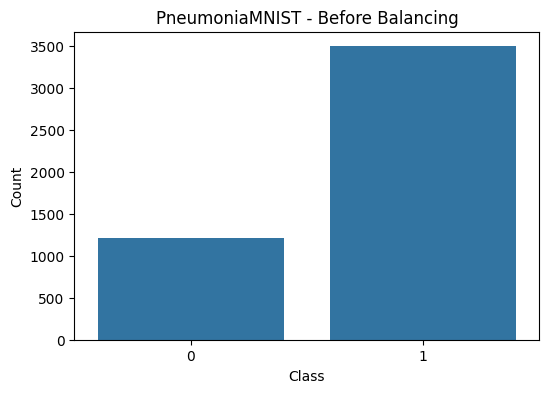

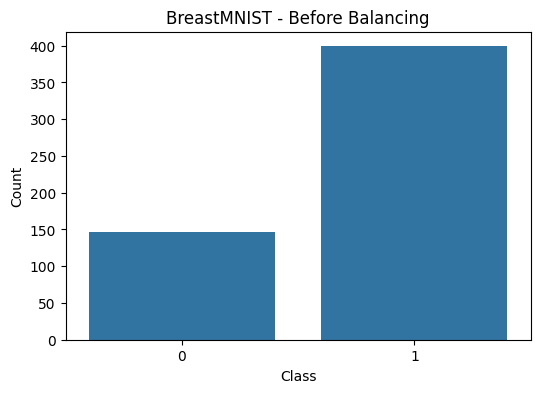

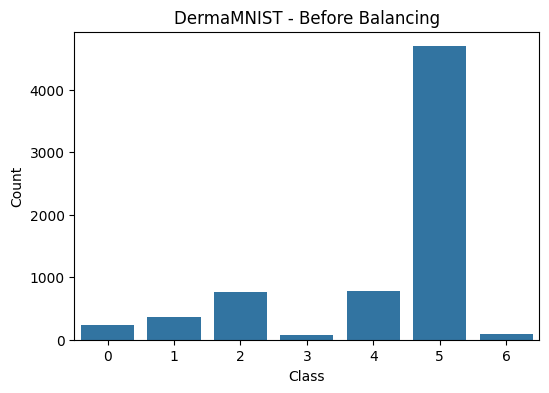

In [11]:
def extract_labels(dataset):
    return np.array([dataset[i][1].item() for i in range(len(dataset))])

labels_pneu_res = extract_labels(train_dataset_pneu_res)
labels_breast_res = extract_labels(train_dataset_breast_res)
labels_derma_res = extract_labels(train_dataset_derma_res)

show_class_dist(labels_pneu_res, 'PneumoniaMNIST - Before Balancing')
show_class_dist(labels_breast_res, 'BreastMNIST - Before Balancing')
show_class_dist(labels_derma_res, 'DermaMNIST - Before Balancing')

In [12]:
labels_pneu_dense = extract_labels(train_dataset_pneu_dense)
labels_breast_dense = extract_labels(train_dataset_breast_dense)
labels_derma_dense = extract_labels(train_dataset_derma_dense)

In [13]:
labels_pneu_eff = extract_labels(train_dataset_pneu_eff)
labels_breast_eff = extract_labels(train_dataset_breast_eff)
labels_derma_eff = extract_labels(train_dataset_derma_eff)

In [14]:
# Raw datasets for original image display in Grad-CAM
_, _, test_pneu_raw, _, _   = load_medmnist_dataset('pneumoniamnist', transform_raw, transform_raw)
_, _, test_breast_raw, _, _ = load_medmnist_dataset('breastmnist', transform_raw, transform_raw)
_, _, test_derma_raw, _, _  = load_medmnist_dataset('dermamnist', transform_raw, transform_raw)

Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\pneumoniamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\breastmnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz
Using downloaded and verified file: C:\Users\nspunn\.medmnist\dermamnist.npz


In [15]:
def compute_class_distribution(labels):
    counter = Counter(labels)
    classes = sorted(counter.keys())
    
    counts = np.array([counter[c] for c in classes])
    total_samples = len(labels)
    
    return classes, counts, total_samples

In [16]:
from sklearn.utils.class_weight import compute_class_weight

def compute_class_weights(labels):
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(labels),
        y=labels
    )
    weights = weights ** 0.5
    return torch.tensor(weights, dtype=torch.float).to(device)

In [17]:
class_weights_pneu_res = compute_class_weights(labels_pneu_res)
class_weights_pneu_res = class_weights_pneu_res / class_weights_pneu_res.mean()
class_weights_pneu_res = torch.clamp(class_weights_pneu_res, min=0.1, max=2.0)

class_weights_pneu_dense = compute_class_weights(labels_pneu_dense)
class_weights_pneu_dense = class_weights_pneu_dense / class_weights_pneu_dense.mean()
class_weights_pneu_dense = torch.clamp(class_weights_pneu_dense, min=0.1, max=2.0)

class_weights_pneu_eff = compute_class_weights(labels_pneu_eff)
class_weights_pneu_eff = class_weights_pneu_eff / class_weights_pneu_eff.mean()
class_weights_pneu_eff = torch.clamp(class_weights_pneu_eff, min=0.1, max=2.0)

In [18]:
class_weights_breast_res = compute_class_weights(labels_breast_res)
class_weights_breast_res = class_weights_breast_res / class_weights_breast_res.mean()
class_weights_breast_res = torch.clamp(class_weights_breast_res, min=0.1, max=2.0)

class_weights_breast_dense = compute_class_weights(labels_breast_dense)
class_weights_breast_dense = class_weights_breast_dense / class_weights_breast_dense.mean()
class_weights_breast_dense = torch.clamp(class_weights_breast_dense, min=0.1, max=2.0)

class_weights_breast_eff = compute_class_weights(labels_breast_eff)
class_weights_breast_eff = class_weights_breast_eff / class_weights_breast_eff.mean()
class_weights_breast_eff = torch.clamp(class_weights_breast_eff, min=0.1, max=2.0)

In [19]:
class_weights_derma_res = compute_class_weights(labels_derma_res)
class_weights_derma_res = class_weights_derma_res / class_weights_derma_res.mean()
class_weights_derma_res = torch.clamp(class_weights_derma_res, min=0.1, max=2.0)

class_weights_derma_dense = compute_class_weights(labels_derma_dense)
class_weights_derma_dense = class_weights_derma_dense / class_weights_derma_dense.mean()
class_weights_derma_dense = torch.clamp(class_weights_derma_dense, min=0.1, max=2.0)

class_weights_derma_eff = compute_class_weights(labels_derma_eff)
class_weights_derma_eff = class_weights_derma_eff / class_weights_derma_eff.mean()
class_weights_derma_eff = torch.clamp(class_weights_derma_eff, min=0.1, max=2.0)

In [20]:
def plot_distribution_and_weights(labels, title):
    
    # ---- Distribution ----
    classes, counts, total = compute_class_distribution(labels)
    
    # ---- Weights ----
    weights = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(labels),
        y=labels
    )
    
    weights_norm = weights / np.max(weights)
    
    # ---- Plot ----
    plt.figure(figsize=(12, 5))
    
    # Left: Distribution
    plt.subplot(1, 2, 1)
    plt.bar(classes, counts)
    plt.title(f"{title} - Class Distribution")
    plt.xlabel("Class")
    plt.ylabel("Samples")
    plt.xticks(classes)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Right: Weights
    plt.subplot(1, 2, 2)
    plt.bar(classes, weights_norm)
    plt.title(f"{title} - Class Weights (Normalized)")
    plt.xlabel("Class")
    plt.ylabel("Weight")
    plt.xticks(classes)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

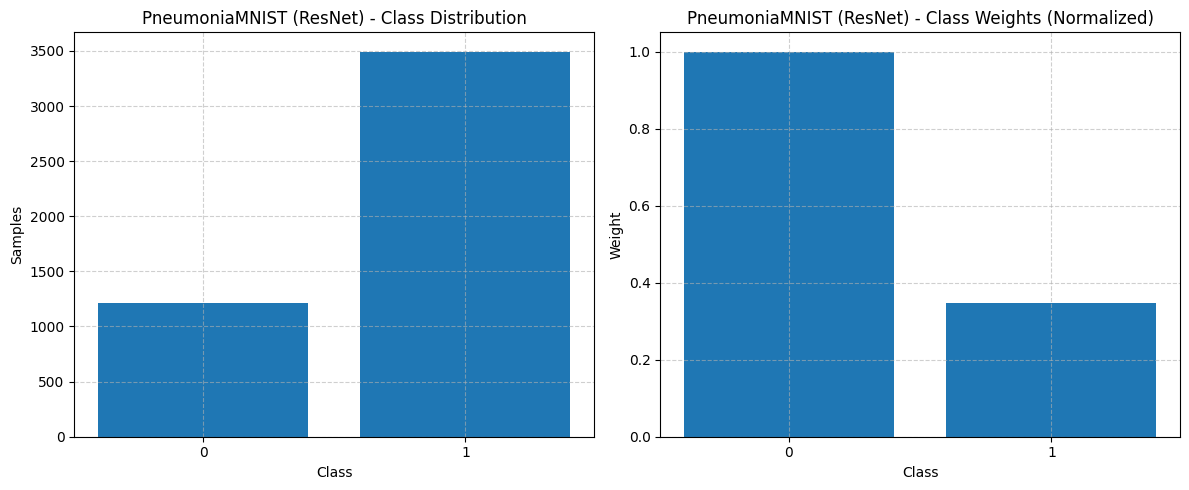

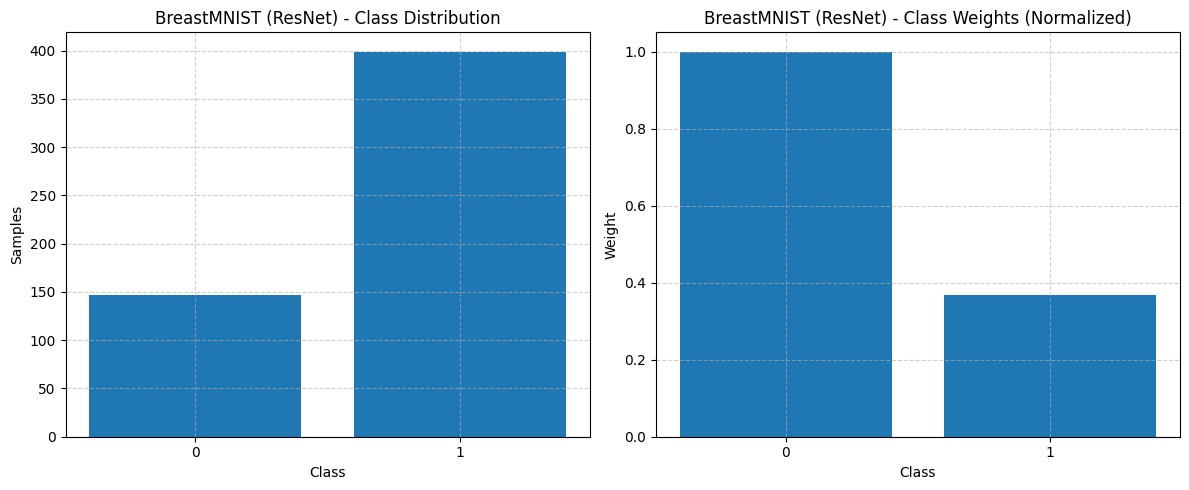

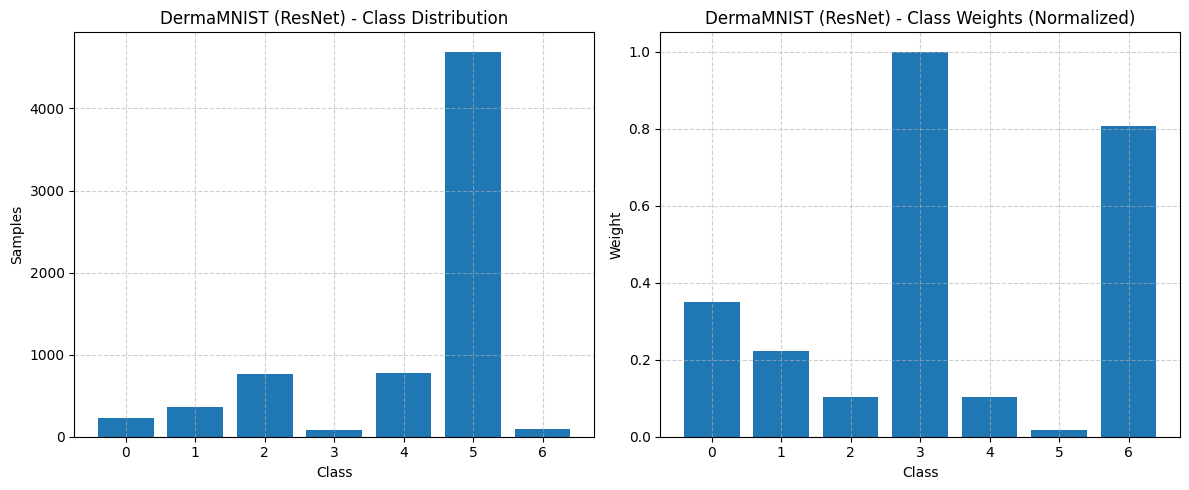

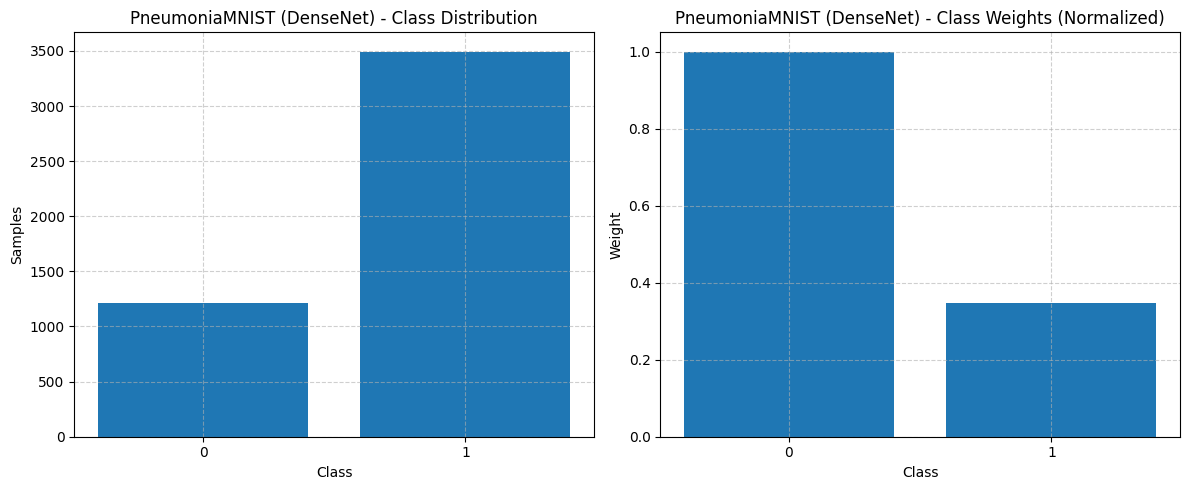

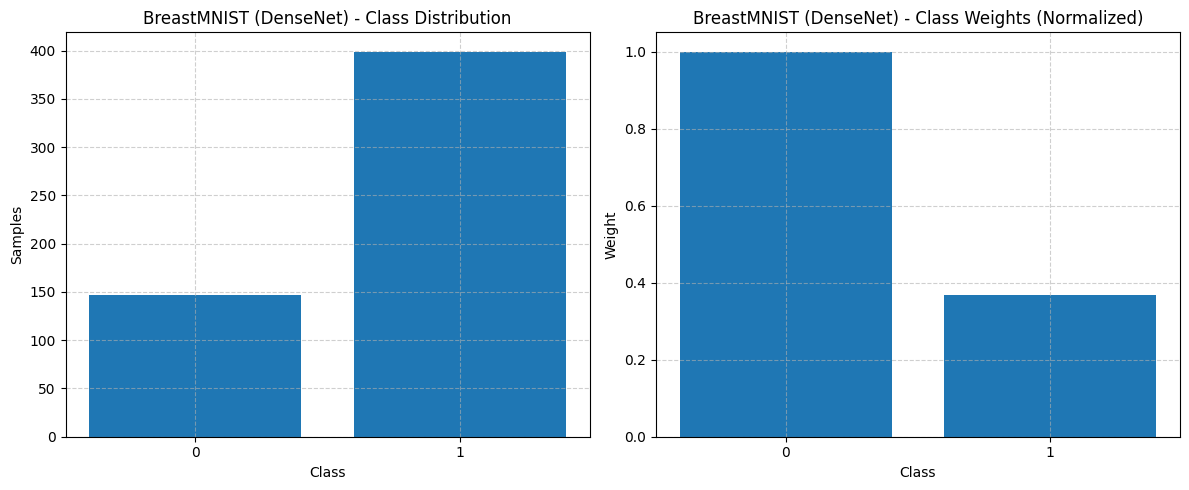

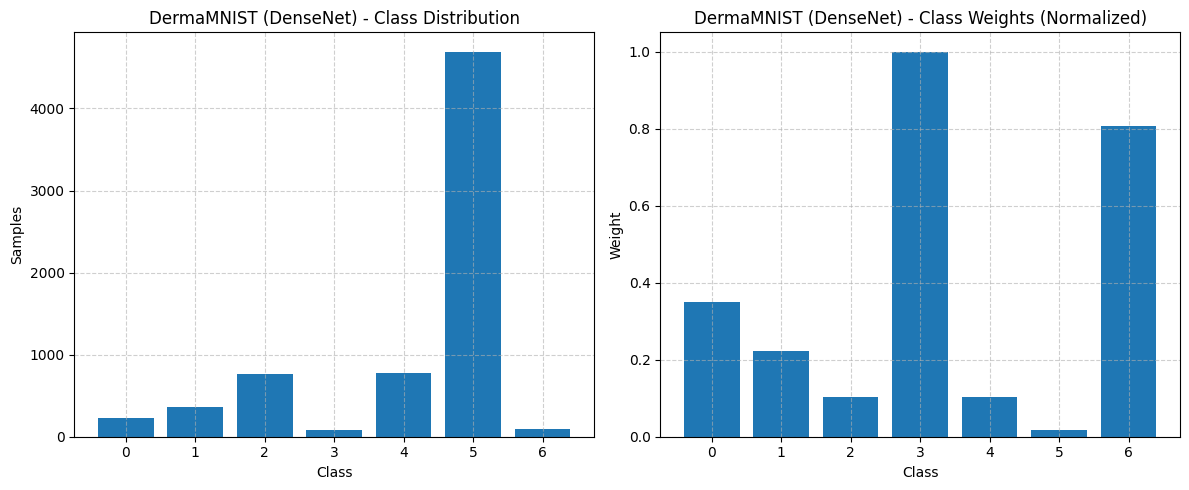

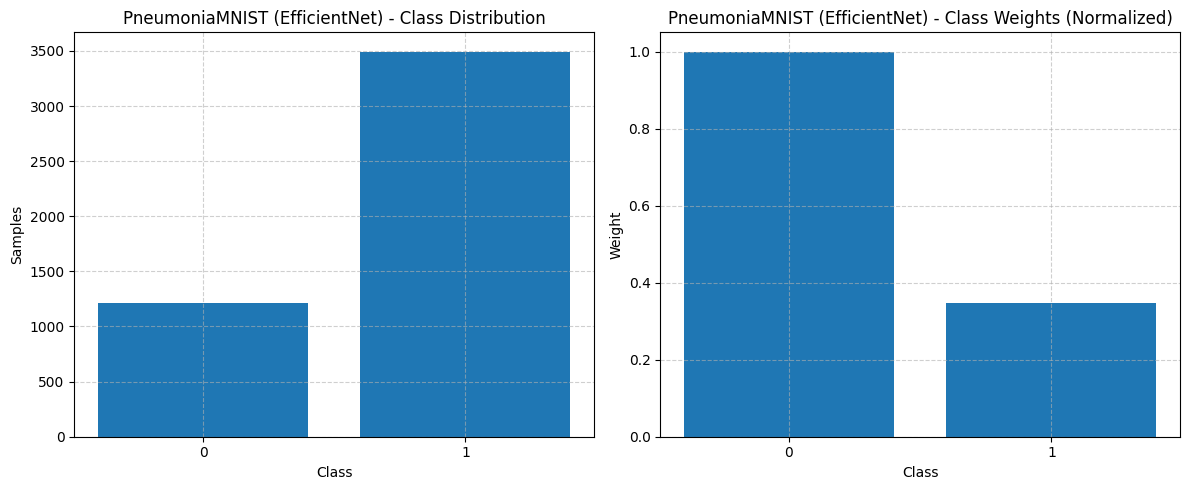

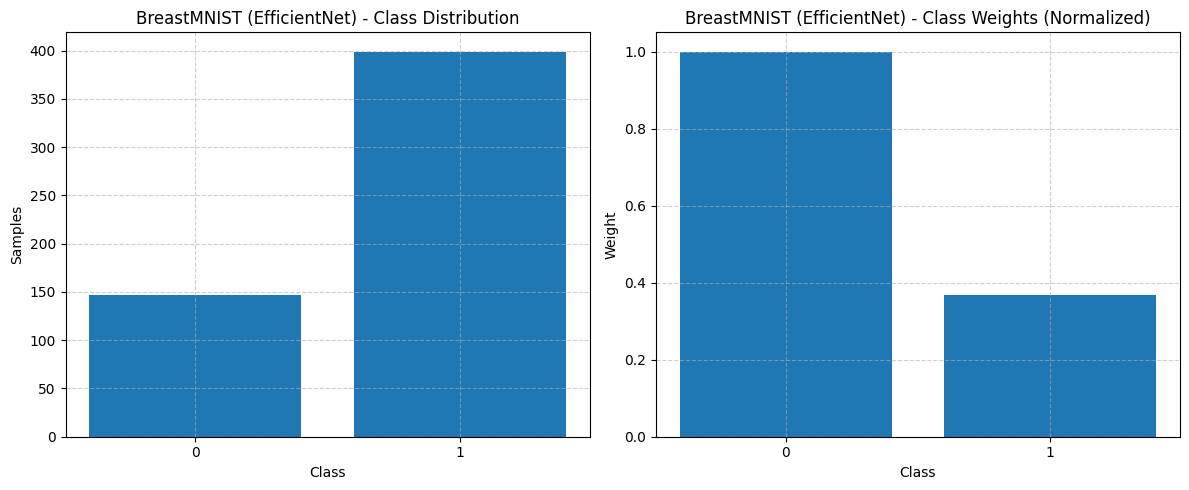

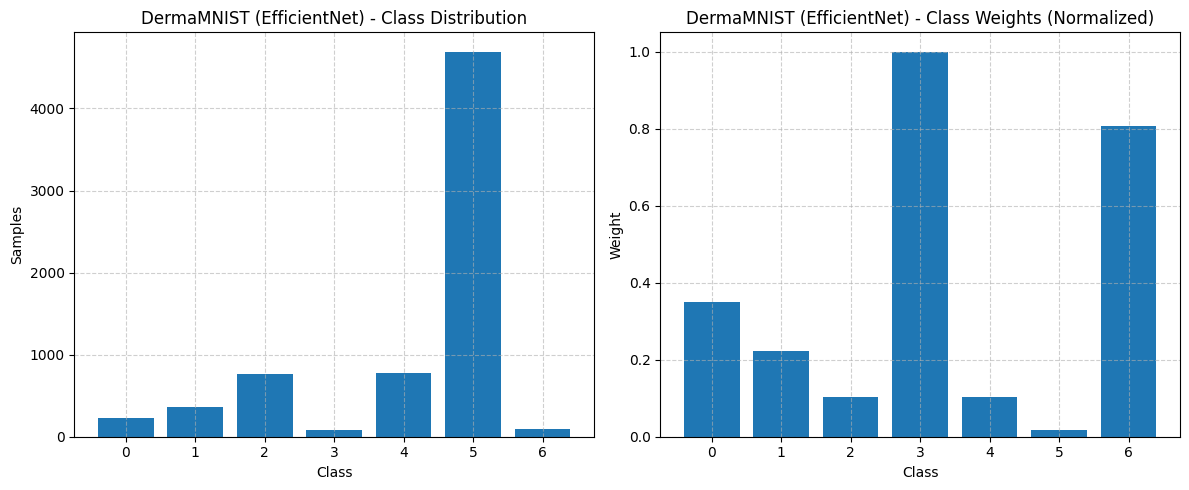

In [21]:
# ---- RESNET ----
plot_distribution_and_weights(labels_pneu_res, "PneumoniaMNIST (ResNet)")
plot_distribution_and_weights(labels_breast_res, "BreastMNIST (ResNet)")
plot_distribution_and_weights(labels_derma_res, "DermaMNIST (ResNet)")

# ---- DENSENET ----
plot_distribution_and_weights(labels_pneu_dense, "PneumoniaMNIST (DenseNet)")
plot_distribution_and_weights(labels_breast_dense, "BreastMNIST (DenseNet)")
plot_distribution_and_weights(labels_derma_dense, "DermaMNIST (DenseNet)")

# ---- EFFICIENTNET ----
plot_distribution_and_weights(labels_pneu_eff, "PneumoniaMNIST (EfficientNet)")
plot_distribution_and_weights(labels_breast_eff, "BreastMNIST (EfficientNet)")
plot_distribution_and_weights(labels_derma_eff, "DermaMNIST (EfficientNet)")

In [22]:
def get_model(model_name, num_classes):
    if model_name == 'resnet':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'densenet':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
        
    elif model_name == 'efficientnet':
        model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        
    return model.to(device)

In [23]:
import copy

class EarlyStopping:
    
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = None
        self.counter = 0
        self.stop = False
        self.best_weights = None
    
    def step(self, loss, model):
        if self.best_loss is None or loss < self.best_loss - self.min_delta:
            self.best_loss = loss
            self.counter = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            self.stop = True
            
    def load_best(self, model):
        model.load_state_dict(self.best_weights)

In [24]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, reduction='none', label_smoothing=0.1)
        pt = torch.exp(-ce_loss)
        
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        if self.alpha is not None:
            at = self.alpha.gather(0, targets)
            focal_loss = at * focal_loss

        return focal_loss.mean()

In [25]:
criterion_default = nn.CrossEntropyLoss()

criterion_derma_res = FocalLoss(gamma=1.5, alpha=class_weights_derma_res)
criterion_derma_dense = FocalLoss(gamma=1.5, alpha=class_weights_derma_dense)
criterion_derma_eff = FocalLoss(gamma=1.5, alpha=class_weights_derma_eff)

In [26]:
NUM_EPOCHS = 50

def train_model(model, train_loader, val_loader, criterion):
    
    #criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    early_stop = EarlyStopping(patience=5)
    
    for epoch in range(NUM_EPOCHS):
        model.train()
        running_loss = 0
        
        for images, labels in tqdm(train_loader):
            images = images.to(device, non_blocking=True)
            labels = labels.view(-1).long().to(device, non_blocking=True)
            
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            running_loss += loss.item()
            
        train_loss = running_loss / len(train_loader)
        
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device, non_blocking=True)
                labels = labels.view(-1).long().to(device, non_blocking=True)
                
                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                
        val_loss /= len(val_loader)
            
        print(f'Epoch [{epoch+1}/{NUM_EPOCHS}] - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f}')
        
        early_stop.step(val_loss, model)
        
        if early_stop.stop:
            print('Early Stopping triggered')
            break
        
    early_stop.load_best(model)
    
    return model

In [27]:
def evaluate_model(model, test_loader):
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.view(-1).long().to(device)
            
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            preds = torch.argmax(probs, dim=1)
            
            all_probs.append(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
    all_probs = np.vstack(all_probs)
    all_labels = np.array(all_labels)
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    rec = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    print(classification_report(all_labels, all_preds, zero_division=0))
    
    return acc, prec, rec, f1, all_probs, all_labels

In [28]:
indv_results = []

In [29]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

def plot_roc_curve(probs, labels, num_classes, title):
    labels_bin = label_binarize(labels, classes=range(num_classes))
    
    plt.figure()
    
    if num_classes == 2:
        fpr, tpr, _ = roc_curve(labels, probs[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    else:
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(labels_bin[:, i], probs[:, i])
            roc_auc = auc(fpr, tpr)
            plt.plot(fpr, tpr, label=f'Class {i} -> AUC = {roc_auc:.2f}')
            
        fpr, tpr, _ = roc_curve(labels_bin.ravel(), probs.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, linestyle='--', label=f'Micro Avg (AUC = {roc_auc:.2f})')
        
    plt.plot([0,1], [0,1], linestyle='--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {title}')
    plt.legend()
    plt.show()

In [30]:
def plot_pr_curve(probs, labels, num_classes, title):

    labels_bin = label_binarize(labels, classes=range(num_classes))

    plt.figure()

    if num_classes == 2:
        precision, recall, _ = precision_recall_curve(labels, probs[:, 1])
        pr_auc = average_precision_score(labels, probs[:, 1])
        plt.plot(recall, precision, label=f'AP = {pr_auc:.2f}')
    
    else:
        for i in range(num_classes):
            precision, recall, _ = precision_recall_curve(labels_bin[:, i], probs[:, i])
            pr_auc = average_precision_score(labels_bin[:, i], probs[:, i])
            plt.plot(recall, precision, label=f'Class {i} (AP = {pr_auc:.2f})')

        precision, recall, _ = precision_recall_curve(labels_bin.ravel(), probs.ravel())
        pr_auc = average_precision_score(labels_bin, probs, average="micro")
        plt.plot(recall, precision, linestyle='--', label=f'Micro Avg (AP = {pr_auc:.2f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'Precision-Recall Curve - {title}')
    plt.legend()
    plt.show()

In [31]:
def get_target_layer(model, model_name):
    if model_name == 'resnet':
        return model.layer4[-1]
    elif model_name == 'densenet':
        return model.features[-1]
    elif model_name == 'efficientnet':
        return model.features[-1]

In [32]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        
        self.gradients = None
        self.activations = None
        
        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output

    def backward_hook(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def generate(self, input_image, class_idx):
        self.model.zero_grad()
        
        output = self.model(input_image)
        loss = output[:, class_idx]
        loss.backward()

        weights = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1)

        cam = torch.relu(cam)
        cam = cam - cam.min()
        cam = cam / cam.max()
        
        return cam.detach().cpu().numpy()

In [33]:
def show_gradcam(model, model_name, dataloader, device, raw_dataset=None):
    model.eval()
    
    images, labels = next(iter(dataloader))
    image = images[0].unsqueeze(0).to(device)
    
    target_layer = get_target_layer(model, model_name)
    gradcam = GradCAM(model, target_layer)
    
    pred = model(image).argmax(dim=1).item()
    
    cam = gradcam.generate(image, pred)[0]
    
    # Get the original (non-normalized) image for display
    if raw_dataset is not None:
        raw_img_tensor, _ = raw_dataset[0]  # get first sample from raw dataset
        orig_img = raw_img_tensor.permute(1, 2, 0).cpu().numpy()
        orig_img = np.clip(orig_img, 0, 1)
    else:
        # Fallback: denormalize the transformed image
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])
        orig_img = image[0].permute(1, 2, 0).cpu().numpy()
        orig_img = std * orig_img + mean
        orig_img = np.clip(orig_img, 0, 1)
    
    # Use normalized image only for the CAM overlay (model-aligned)
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img_for_cam = image[0].permute(1, 2, 0).cpu().numpy()
    img_for_cam = std * img_for_cam + mean
    img_for_cam = np.clip(img_for_cam, 0, 1)
    
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.title("Original Image")
    plt.imshow(orig_img)
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM")
    plt.imshow(img_for_cam)
    plt.imshow(cam, cmap='jet', alpha=0.5)
    plt.axis('off')
    
    plt.show()

In [34]:
resnet_pneu = get_model('resnet', len(info_pneu_res['label']))
resnet_pneu = resnet_pneu.to(device)
resnet_pneu = train_model(resnet_pneu, train_pneu_res, val_pneu_res, criterion_default)
acc_resnet_pneu, prec_resnet_pneu, rec_resnet_pneu, f1_resnet_pneu, probs_resnet_pneu, lab_resnet_pneu = evaluate_model(resnet_pneu, test_pneu_res)

indv_results.append({
    'Model': 'ResNet50',
    'Dataset': 'PneumoniaMNIST',
    'Accuracy': acc_resnet_pneu,
    'Precision': prec_resnet_pneu,
    'Recall': rec_resnet_pneu,
    'F1-Score': f1_resnet_pneu
})

100%|██████████| 74/74 [00:17<00:00,  4.33it/s]


Epoch [1/50] - Train Loss: 0.1451 - Val Loss: 0.0794


100%|██████████| 74/74 [00:14<00:00,  5.18it/s]


Epoch [2/50] - Train Loss: 0.0581 - Val Loss: 0.0783


100%|██████████| 74/74 [00:14<00:00,  5.18it/s]


...

Epoch [8/50] - Train Loss: 0.0080 - Val Loss: 0.0761


100%|██████████| 74/74 [00:14<00:00,  5.16it/s]


Epoch [9/50] - Train Loss: 0.0065 - Val Loss: 0.0993


100%|██████████| 74/74 [00:14<00:00,  5.16it/s]


Epoch [10/50] - Train Loss: 0.0173 - Val Loss: 0.1007
Early Stopping triggered
              precision    recall  f1-score   support

           0       1.00      0.54      0.70       234
           1       0.78      1.00      0.88       390

    accuracy                           0.83       624
   macro avg       0.89      0.77      0.79       624
weighted avg       0.87      0.83      0.81       624



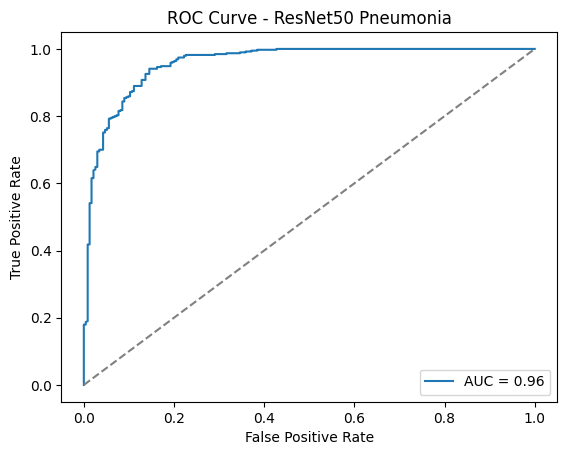

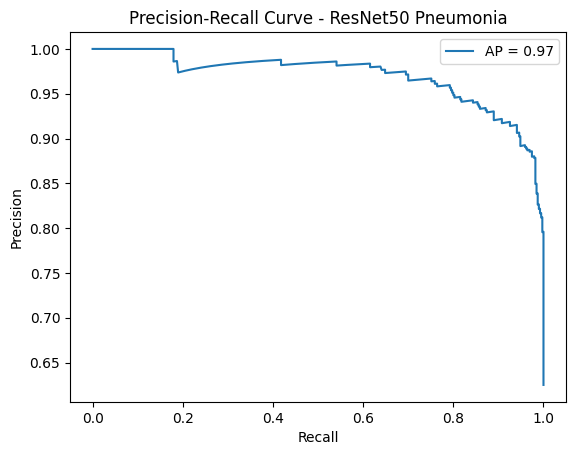

In [35]:
num_classes_resnet_pneu = probs_resnet_pneu.shape[1]

plot_roc_curve(probs_resnet_pneu, lab_resnet_pneu, num_classes_resnet_pneu, 'ResNet50 Pneumonia')
plot_pr_curve(probs_resnet_pneu, lab_resnet_pneu, num_classes_resnet_pneu, 'ResNet50 Pneumonia')

d:\miniconda\envs\akash_310\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


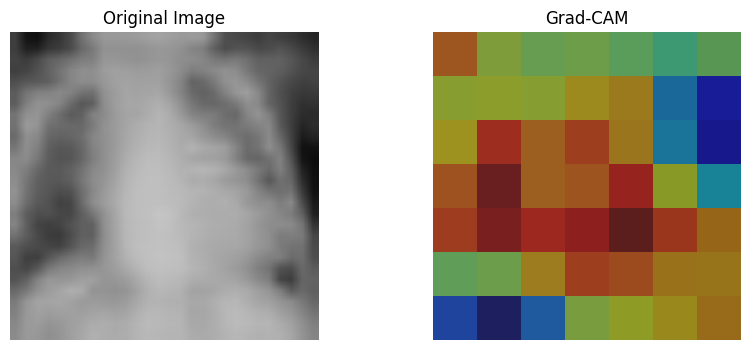

In [36]:
show_gradcam(resnet_pneu, 'resnet', test_pneu_res, device, raw_dataset=test_pneu_raw.dataset)

In [37]:
resnet_breast = get_model('resnet', len(info_breast_res['label']))
resnet_breast = resnet_breast.to(device)
resnet_breast = train_model(resnet_breast, train_breast_res, val_breast_res, criterion_default)
acc_resnet_breast, prec_resnet_breast, rec_resnet_breast, f1_resnet_breast, probs_resnet_breast, lab_resnet_breast = evaluate_model(resnet_breast, test_breast_res)

indv_results.append({
    'Model': 'ResNet50',
    'Dataset': 'BreastMNIST',
    'Accuracy': acc_resnet_breast,
    'Precision': prec_resnet_breast,
    'Recall': rec_resnet_breast,
    'F1-Score': f1_resnet_breast
})

100%|██████████| 9/9 [00:02<00:00,  3.28it/s]


Epoch [1/50] - Train Loss: 0.5435 - Val Loss: 0.4418


100%|██████████| 9/9 [00:01<00:00,  5.22it/s]


Epoch [2/50] - Train Loss: 0.1898 - Val Loss: 0.3666


100%|██████████| 9/9 [00:01<00:00,  5.30it/s]


...

Epoch [5/50] - Train Loss: 0.0049 - Val Loss: 0.4397


100%|██████████| 9/9 [00:01<00:00,  5.32it/s]


Epoch [6/50] - Train Loss: 0.0026 - Val Loss: 0.5174


100%|██████████| 9/9 [00:01<00:00,  5.34it/s]


Epoch [7/50] - Train Loss: 0.0016 - Val Loss: 0.4271
Early Stopping triggered
              precision    recall  f1-score   support

           0       0.93      0.33      0.49        42
           1       0.80      0.99      0.89       114

    accuracy                           0.81       156
   macro avg       0.87      0.66      0.69       156
weighted avg       0.84      0.81      0.78       156



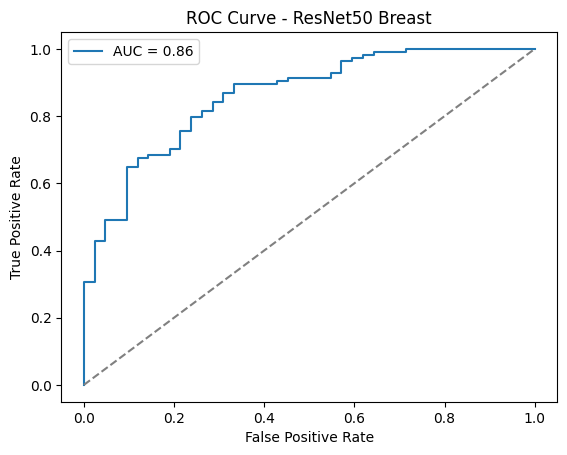

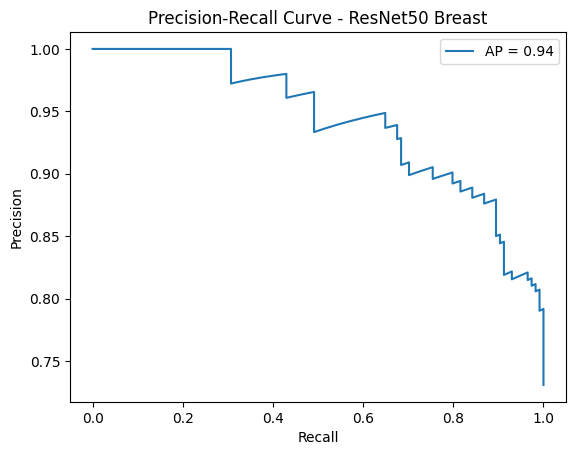

In [38]:
num_classes_resnet_breast = probs_resnet_breast.shape[1]

plot_roc_curve(probs_resnet_breast, lab_resnet_breast, num_classes_resnet_breast, 'ResNet50 Breast')
plot_pr_curve(probs_resnet_breast, lab_resnet_breast, num_classes_resnet_breast, 'ResNet50 Breast')

d:\miniconda\envs\akash_310\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


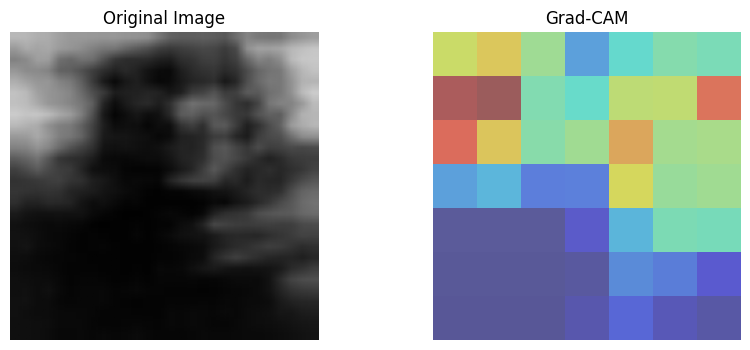

In [39]:
show_gradcam(resnet_breast, 'resnet', test_breast_res, device, test_breast_raw.dataset)

In [40]:
resnet_derma = get_model('resnet', len(info_derma_res['label']))
resnet_derma = resnet_derma.to(device)
resnet_derma = train_model(resnet_derma, train_derma_res, val_derma_res, criterion_derma_res)
acc_resnet_derma, prec_resnet_derma, rec_resnet_derma, f1_resnet_derma, probs_resnet_derma, lab_resnet_derma = evaluate_model(resnet_derma, test_derma_res)

indv_results.append({
    'Model': 'Resnet50',
    'Dataset': 'DermaMNIST',
    'Accuracy': acc_resnet_derma,
    'Precision': prec_resnet_derma,
    'Recall': rec_resnet_derma,
    'F1-Score': f1_resnet_derma
})

100%|██████████| 110/110 [00:39<00:00,  2.79it/s]


Epoch [1/50] - Train Loss: 0.3956 - Val Loss: 0.3484


100%|██████████| 110/110 [00:38<00:00,  2.87it/s]


Epoch [2/50] - Train Loss: 0.3343 - Val Loss: 0.3161


100%|██████████| 110/110 [00:38<00:00,  2.86it/s]


...

Epoch [11/50] - Train Loss: 0.2304 - Val Loss: 0.2947


100%|██████████| 110/110 [00:38<00:00,  2.87it/s]


Epoch [12/50] - Train Loss: 0.2142 - Val Loss: 0.3010


100%|██████████| 110/110 [00:38<00:00,  2.87it/s]


Epoch [13/50] - Train Loss: 0.2142 - Val Loss: 0.3409
Early Stopping triggered
              precision    recall  f1-score   support

           0       0.29      0.39      0.34        66
           1       0.46      0.63      0.53       103
           2       0.57      0.37      0.45       220
           3       0.39      0.52      0.44        23
           4       0.42      0.57      0.48       223
           5       0.91      0.84      0.88      1341
           6       0.45      0.93      0.61        29

    accuracy                           0.73      2005
   macro avg       0.50      0.61      0.53      2005
weighted avg       0.76      0.73      0.74      2005



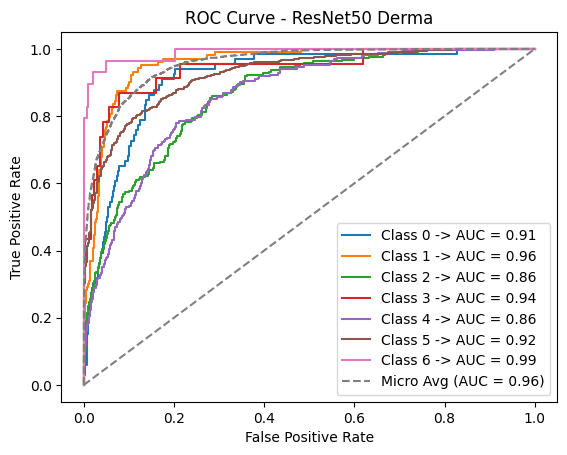

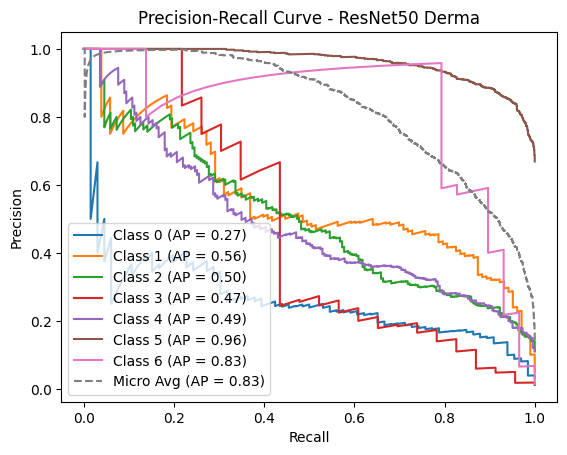

In [41]:
num_classes_resnet_derma = probs_resnet_derma.shape[1]

plot_roc_curve(probs_resnet_derma, lab_resnet_derma, num_classes_resnet_derma, 'ResNet50 Derma')
plot_pr_curve(probs_resnet_derma, lab_resnet_derma, num_classes_resnet_derma, 'ResNet50 Derma')

d:\miniconda\envs\akash_310\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


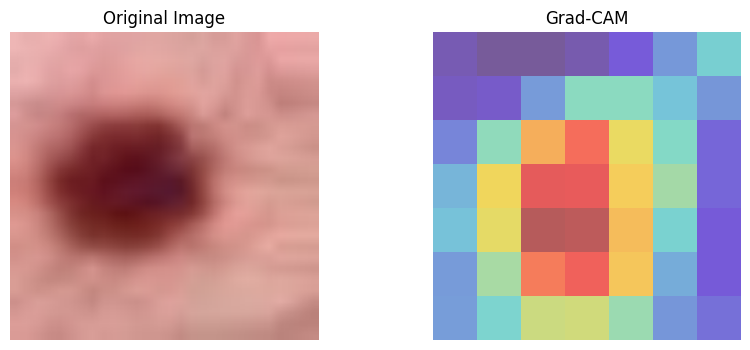

In [42]:
show_gradcam(resnet_derma, 'resnet', test_derma_res, device, test_derma_raw.dataset)

In [43]:
densenet_pneu = get_model('densenet', len(info_pneu_dense['label']))
densenet_pneu = densenet_pneu.to(device)
densenet_pneu = train_model(densenet_pneu, train_pneu_dense, val_pneu_dense, criterion_default)
acc_densenet_pneu, prec_densenet_pneu, rec_densenet_pneu, f1_densenet_pneu, probs_densenet_pneu, lab_densenet_pneu = evaluate_model(densenet_pneu, test_pneu_dense)

indv_results.append({
    'Model': 'DenseNet121',
    'Dataset': 'PneumoniaMNIST',
    'Accuracy': acc_densenet_pneu,
    'Precision': prec_densenet_pneu,
    'Recall': rec_densenet_pneu,
    'F1-Score': f1_densenet_pneu
})

100%|██████████| 74/74 [00:20<00:00,  3.57it/s]


Epoch [1/50] - Train Loss: 0.2079 - Val Loss: 0.1764


100%|██████████| 74/74 [00:17<00:00,  4.34it/s]


Epoch [2/50] - Train Loss: 0.0624 - Val Loss: 0.0648


100%|██████████| 74/74 [00:16<00:00,  4.35it/s]


...

Epoch [12/50] - Train Loss: 0.0014 - Val Loss: 0.0645


100%|██████████| 74/74 [00:17<00:00,  4.34it/s]


Epoch [13/50] - Train Loss: 0.0292 - Val Loss: 0.0923


100%|██████████| 74/74 [00:16<00:00,  4.37it/s]


Epoch [14/50] - Train Loss: 0.0254 - Val Loss: 0.0570
Early Stopping triggered
              precision    recall  f1-score   support

           0       0.99      0.72      0.84       234
           1       0.86      1.00      0.92       390

    accuracy                           0.89       624
   macro avg       0.93      0.86      0.88       624
weighted avg       0.91      0.89      0.89       624



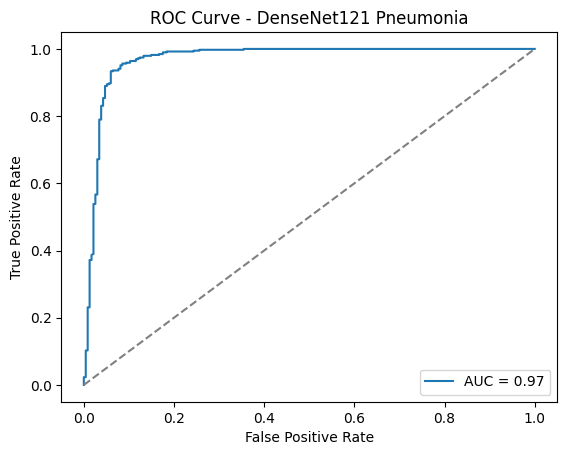

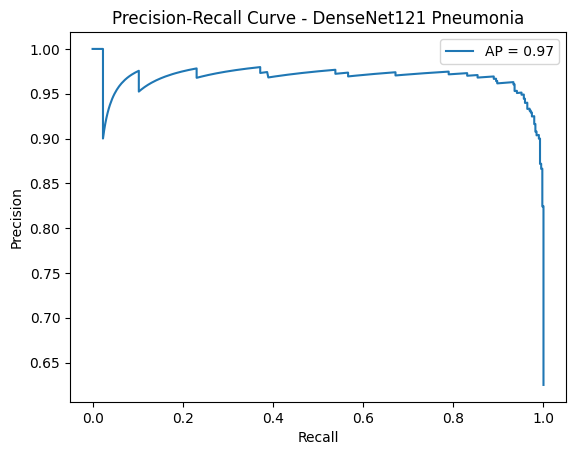

In [44]:
num_classes_densenet_pneu = probs_densenet_pneu.shape[1]

plot_roc_curve(probs_densenet_pneu, lab_densenet_pneu, num_classes_densenet_pneu, 'DenseNet121 Pneumonia')
plot_pr_curve(probs_densenet_pneu, lab_densenet_pneu, num_classes_densenet_pneu, 'DenseNet121 Pneumonia')

d:\miniconda\envs\akash_310\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


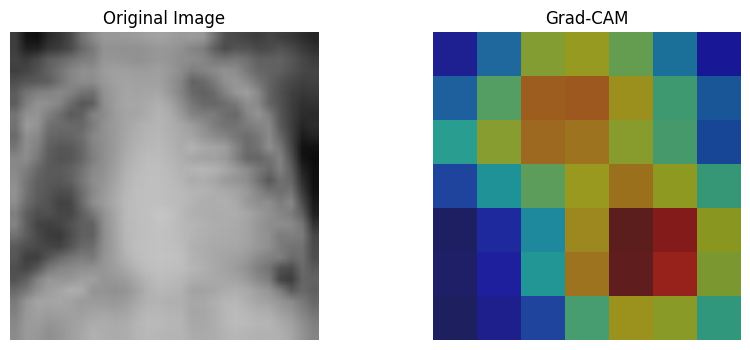

In [45]:
show_gradcam(densenet_pneu, 'densenet', test_pneu_dense, device, test_pneu_raw.dataset)

In [46]:
densenet_breast = get_model('densenet', len(info_breast_dense['label']))
densenet_breast = densenet_breast.to(device)
densenet_breast = train_model(densenet_breast, train_breast_dense, val_breast_dense, criterion_default)
acc_densenet_breast, prec_densenet_breast, rec_densenet_breast, f1_densenet_breast, probs_densenet_breast, lab_densenet_breast = evaluate_model(densenet_breast, test_breast_dense)

indv_results.append({
    'Model': 'DenseNet121',
    'Dataset': 'BreastMNIST',
    'Accuracy': acc_densenet_breast,
    'Precision': prec_densenet_breast,
    'Recall': rec_densenet_breast,
    'F1-Score': f1_densenet_breast
})

100%|██████████| 9/9 [00:03<00:00,  2.41it/s]


Epoch [1/50] - Train Loss: 0.6135 - Val Loss: 0.5574


100%|██████████| 9/9 [00:02<00:00,  4.36it/s]


Epoch [2/50] - Train Loss: 0.2880 - Val Loss: 0.4374


100%|██████████| 9/9 [00:01<00:00,  4.53it/s]


...

Epoch [9/50] - Train Loss: 0.0046 - Val Loss: 0.2527


100%|██████████| 9/9 [00:01<00:00,  4.52it/s]


Epoch [10/50] - Train Loss: 0.0041 - Val Loss: 0.2483


100%|██████████| 9/9 [00:01<00:00,  4.52it/s]


Epoch [11/50] - Train Loss: 0.0048 - Val Loss: 0.2494
Early Stopping triggered
              precision    recall  f1-score   support

           0       0.88      0.55      0.68        42
           1       0.85      0.97      0.91       114

    accuracy                           0.86       156
   macro avg       0.87      0.76      0.79       156
weighted avg       0.86      0.86      0.85       156



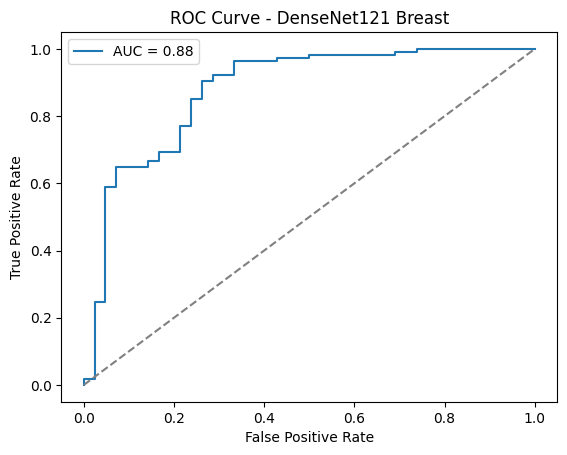

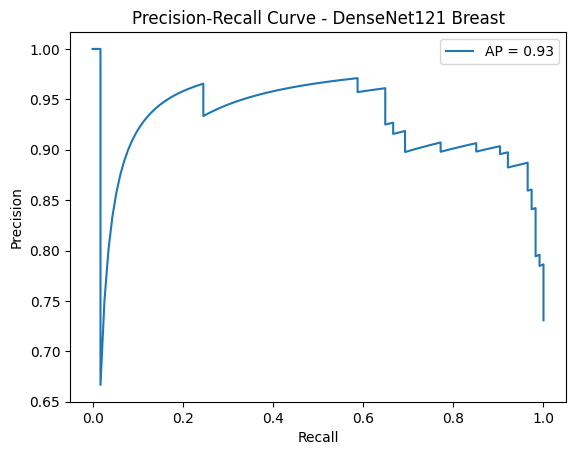

In [47]:
num_classes_densenet_breast = probs_densenet_breast.shape[1]

plot_roc_curve(probs_densenet_breast, lab_densenet_breast, num_classes_densenet_breast, 'DenseNet121 Breast')
plot_pr_curve(probs_densenet_breast, lab_densenet_breast, num_classes_densenet_breast, 'DenseNet121 Breast')

d:\miniconda\envs\akash_310\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


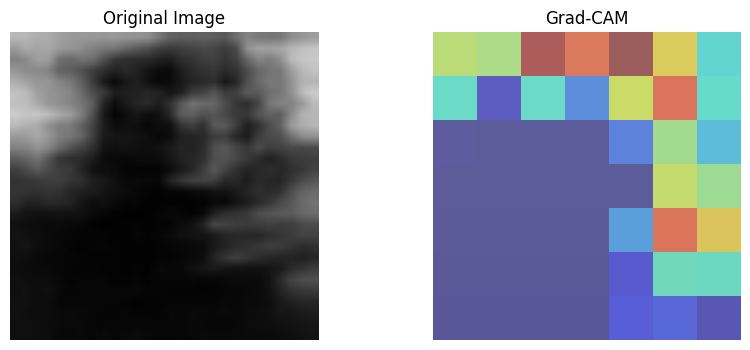

In [48]:
show_gradcam(densenet_breast, 'densenet', test_breast_dense, device, test_breast_raw.dataset)

In [49]:
densenet_derma = get_model('densenet', len(info_derma_dense['label']))
densenet_derma = densenet_derma.to(device)
densenet_derma = train_model(densenet_derma, train_derma_dense, val_derma_dense, criterion_derma_dense)
acc_densenet_derma, prec_densenet_derma, rec_densenet_derma, f1_densenet_derma, probs_densenet_derma, lab_densenet_derma = evaluate_model(densenet_derma, test_derma_dense)

indv_results.append({
    'Model': 'DenseNet121',
    'Dataset': 'DermaMNIST',
    'Accuracy': acc_densenet_derma,
    'Precision': prec_densenet_derma,
    'Recall': rec_densenet_derma,
    'F1-Score': f1_densenet_derma
})

100%|██████████| 110/110 [00:43<00:00,  2.53it/s]


Epoch [1/50] - Train Loss: 0.4318 - Val Loss: 0.3258


100%|██████████| 110/110 [00:41<00:00,  2.63it/s]


Epoch [2/50] - Train Loss: 0.3281 - Val Loss: 0.3154


100%|██████████| 110/110 [00:41<00:00,  2.64it/s]


...

Epoch [7/50] - Train Loss: 0.2541 - Val Loss: 0.3075


100%|██████████| 110/110 [00:41<00:00,  2.63it/s]


Epoch [8/50] - Train Loss: 0.2484 - Val Loss: 0.3071


100%|██████████| 110/110 [00:41<00:00,  2.63it/s]


Epoch [9/50] - Train Loss: 0.2350 - Val Loss: 0.2980
Early Stopping triggered
              precision    recall  f1-score   support

           0       0.41      0.58      0.48        66
           1       0.49      0.60      0.54       103
           2       0.60      0.45      0.52       220
           3       0.45      0.43      0.44        23
           4       0.48      0.58      0.53       223
           5       0.91      0.87      0.89      1341
           6       0.52      0.90      0.66        29

    accuracy                           0.76      2005
   macro avg       0.55      0.63      0.58      2005
weighted avg       0.78      0.76      0.77      2005



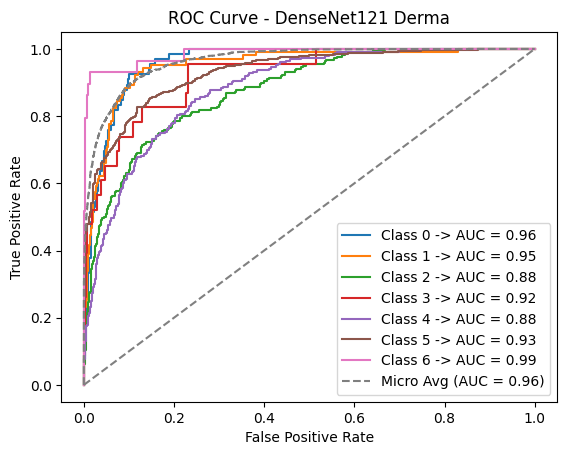

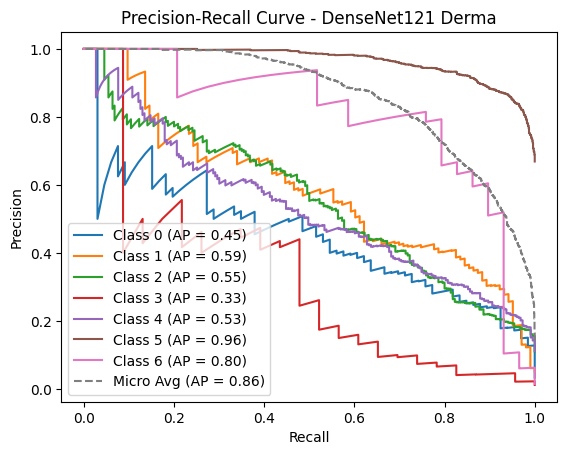

In [50]:
num_classes_densenet_derma = probs_densenet_derma.shape[1]

plot_roc_curve(probs_densenet_derma, lab_densenet_derma, num_classes_densenet_derma, 'DenseNet121 Derma')
plot_pr_curve(probs_densenet_derma, lab_densenet_derma, num_classes_densenet_derma, 'DenseNet121 Derma')

d:\miniconda\envs\akash_310\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


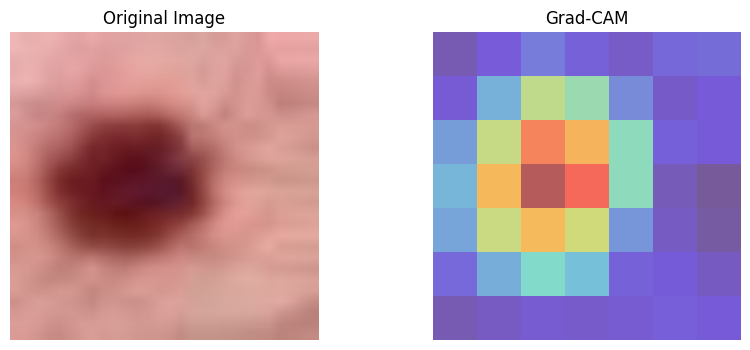

In [51]:
show_gradcam(densenet_derma, 'densenet', test_derma_dense, device, test_derma_raw.dataset)

In [52]:
efficientnet_pneu = get_model('efficientnet', len(info_pneu_eff['label']))
efficientnet_pneu = efficientnet_pneu.to(device)
efficientnet_pneu = train_model(efficientnet_pneu, train_pneu_eff, val_pneu_eff, criterion_default)
acc_efficientnet_pneu, prec_efficientnet_pneu, rec_efficientnet_pneu, f1_efficientnet_pneu, probs_efficientnet_pneu, lab_efficientnet_pneu = evaluate_model(efficientnet_pneu, test_pneu_eff)

indv_results.append({
    'Model': 'EfficientNetB0',
    'Dataset': 'PneumoniaMNIST',
    'Accuracy': acc_efficientnet_pneu,
    'Precision': prec_efficientnet_pneu,
    'Recall': rec_efficientnet_pneu,
    'F1-Score': f1_efficientnet_pneu
})

100%|██████████| 74/74 [00:19<00:00,  3.78it/s]


Epoch [1/50] - Train Loss: 0.2472 - Val Loss: 0.1132


100%|██████████| 74/74 [00:11<00:00,  6.39it/s]


Epoch [2/50] - Train Loss: 0.0856 - Val Loss: 0.1075


100%|██████████| 74/74 [00:11<00:00,  6.45it/s]


...

Epoch [10/50] - Train Loss: 0.0045 - Val Loss: 0.1385


100%|██████████| 74/74 [00:11<00:00,  6.38it/s]


Epoch [11/50] - Train Loss: 0.0059 - Val Loss: 0.1507


100%|██████████| 74/74 [00:11<00:00,  6.41it/s]


Epoch [12/50] - Train Loss: 0.0130 - Val Loss: 0.1233
Early Stopping triggered
              precision    recall  f1-score   support

           0       0.97      0.66      0.79       234
           1       0.83      0.99      0.90       390

    accuracy                           0.87       624
   macro avg       0.90      0.83      0.85       624
weighted avg       0.88      0.87      0.86       624



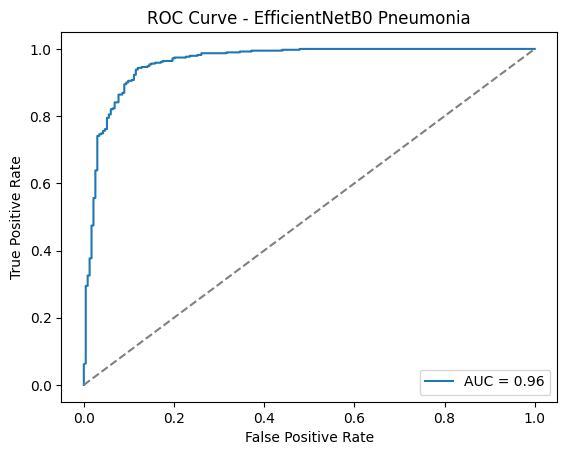

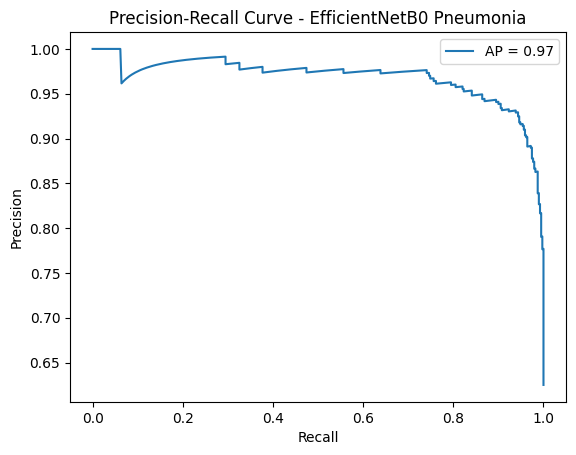

In [53]:
num_classes_efficientnet_pneu = probs_efficientnet_pneu.shape[1]

plot_roc_curve(probs_efficientnet_pneu, lab_efficientnet_pneu, num_classes_efficientnet_pneu, 'EfficientNetB0 Pneumonia')
plot_pr_curve(probs_efficientnet_pneu, lab_efficientnet_pneu, num_classes_efficientnet_pneu, 'EfficientNetB0 Pneumonia')

d:\miniconda\envs\akash_310\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


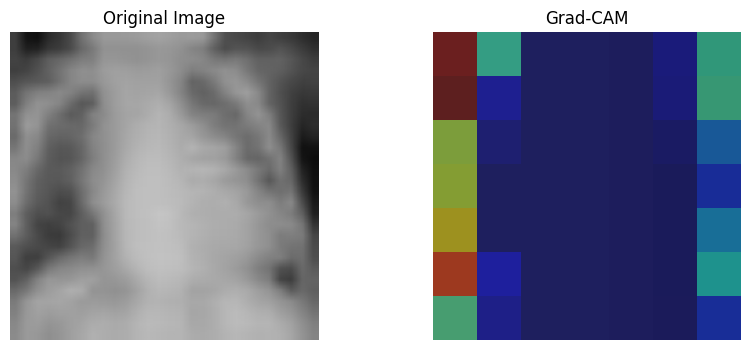

In [54]:
show_gradcam(efficientnet_pneu, 'efficientnet', test_pneu_eff, device, test_pneu_raw.dataset)

In [55]:
efficientnet_breast = get_model('efficientnet', len(info_breast_eff['label']))
efficientnet_breast = efficientnet_breast.to(device)
efficientnet_breast = train_model(efficientnet_breast, train_breast_eff, val_breast_eff, criterion_default)
acc_efficientnet_breast, prec_efficientnet_breast, rec_efficientnet_breast, f1_efficientnet_breast, probs_efficientnet_breast, lab_efficientnet_breast = evaluate_model(efficientnet_breast, test_breast_eff)

indv_results.append({
    'Model': 'EfficientNetB0',
    'Dataset': 'BreastMNIST',
    'Accuracy': acc_efficientnet_breast,
    'Precision': prec_efficientnet_breast,
    'Recall': rec_efficientnet_breast,
    'F1-Score': f1_efficientnet_breast
})

100%|██████████| 9/9 [00:04<00:00,  2.17it/s]


Epoch [1/50] - Train Loss: 0.6247 - Val Loss: 0.6457


100%|██████████| 9/9 [00:01<00:00,  6.35it/s]


Epoch [2/50] - Train Loss: 0.4687 - Val Loss: 0.6150


100%|██████████| 9/9 [00:01<00:00,  6.46it/s]


...

Epoch [13/50] - Train Loss: 0.0334 - Val Loss: 0.2673


100%|██████████| 9/9 [00:01<00:00,  6.59it/s]


Epoch [14/50] - Train Loss: 0.0342 - Val Loss: 0.2803


100%|██████████| 9/9 [00:01<00:00,  6.59it/s]


Epoch [15/50] - Train Loss: 0.0210 - Val Loss: 0.2865
Early Stopping triggered
              precision    recall  f1-score   support

           0       0.76      0.62      0.68        42
           1       0.87      0.93      0.90       114

    accuracy                           0.85       156
   macro avg       0.82      0.77      0.79       156
weighted avg       0.84      0.85      0.84       156



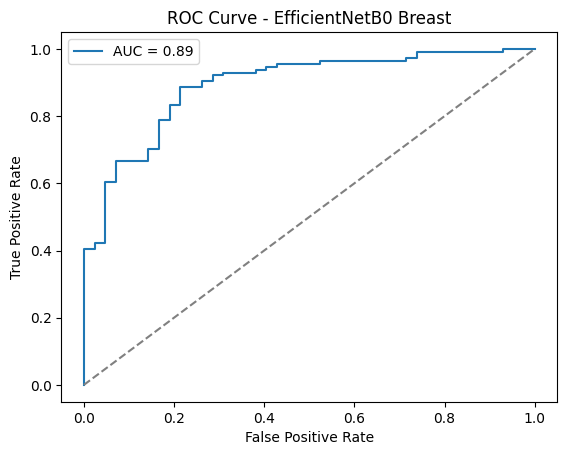

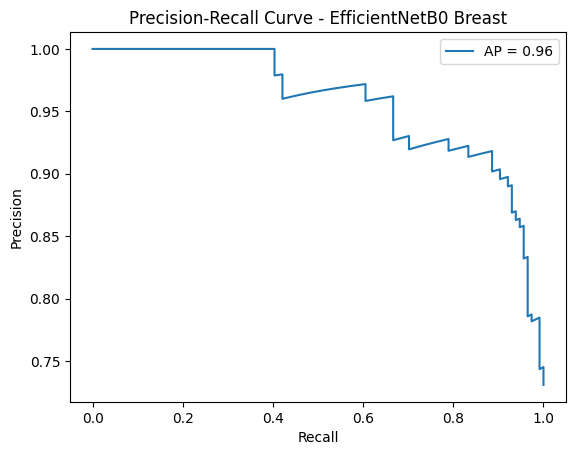

In [56]:
num_classes_efficientnet_breast = probs_efficientnet_breast.shape[1]

plot_roc_curve(probs_efficientnet_breast, lab_efficientnet_breast, num_classes_efficientnet_breast, 'EfficientNetB0 Breast')
plot_pr_curve(probs_efficientnet_breast, lab_efficientnet_breast, num_classes_efficientnet_breast, 'EfficientNetB0 Breast')

d:\miniconda\envs\akash_310\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


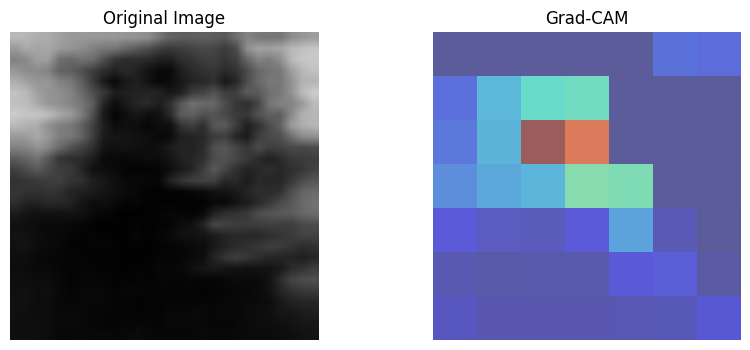

In [57]:
show_gradcam(efficientnet_breast, 'efficientnet', test_breast_eff, device, test_breast_raw.dataset)

In [58]:
efficientnet_derma = get_model('efficientnet', len(info_derma_eff['label']))
efficientnet_derma = efficientnet_derma.to(device)
efficientnet_derma = train_model(efficientnet_derma, train_derma_eff, val_derma_eff, criterion_derma_eff)
acc_efficientnet_derma, prec_efficientnet_derma, rec_efficientnet_derma, f1_efficientnet_derma, probs_efficientnet_derma, lab_efficientnet_derma = evaluate_model(efficientnet_derma, test_derma_eff)

indv_results.append({
    'Model': 'EfficientNetB0',
    'Dataset': 'DermaMNIST',
    'Accuracy': acc_efficientnet_derma,
    'Precision': prec_efficientnet_derma,
    'Recall': rec_efficientnet_derma,
    'F1-Score': f1_efficientnet_derma
})

100%|██████████| 110/110 [00:36<00:00,  3.01it/s]


Epoch [1/50] - Train Loss: 0.4775 - Val Loss: 0.3951


100%|██████████| 110/110 [00:33<00:00,  3.25it/s]


Epoch [2/50] - Train Loss: 0.3547 - Val Loss: 0.3434


100%|██████████| 110/110 [00:33<00:00,  3.24it/s]


...

Epoch [13/50] - Train Loss: 0.2111 - Val Loss: 0.3015


100%|██████████| 110/110 [00:33<00:00,  3.24it/s]


Epoch [14/50] - Train Loss: 0.2044 - Val Loss: 0.2910


100%|██████████| 110/110 [00:33<00:00,  3.24it/s]


Epoch [15/50] - Train Loss: 0.1934 - Val Loss: 0.3018
Early Stopping triggered
              precision    recall  f1-score   support

           0       0.43      0.45      0.44        66
           1       0.46      0.68      0.55       103
           2       0.59      0.47      0.53       220
           3       0.47      0.30      0.37        23
           4       0.45      0.60      0.52       223
           5       0.92      0.85      0.88      1341
           6       0.53      0.90      0.67        29

    accuracy                           0.75      2005
   macro avg       0.55      0.61      0.56      2005
weighted avg       0.78      0.75      0.76      2005



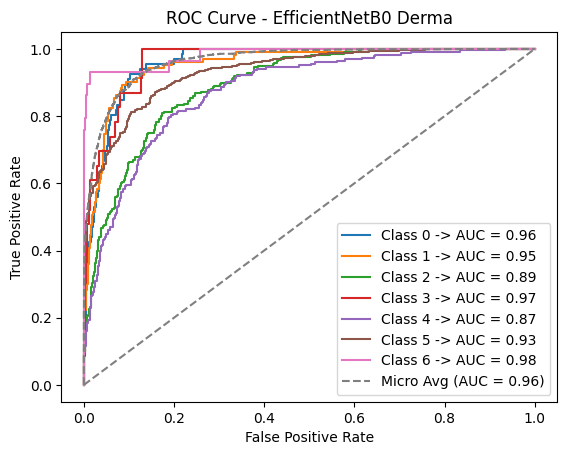

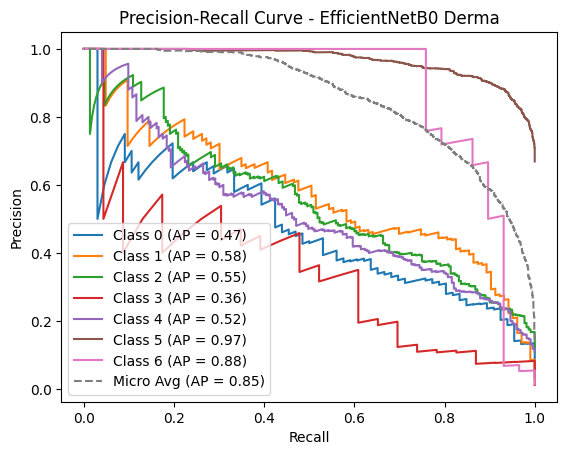

In [59]:
num_classes_efficientnet_derma = probs_efficientnet_derma.shape[1]

plot_roc_curve(probs_efficientnet_derma, lab_efficientnet_derma, num_classes_efficientnet_derma, 'EfficientNetB0 Derma')
plot_pr_curve(probs_efficientnet_derma, lab_efficientnet_derma, num_classes_efficientnet_derma, 'EfficientNetB0 Derma')

d:\miniconda\envs\akash_310\lib\site-packages\torch\nn\modules\module.py:1827: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


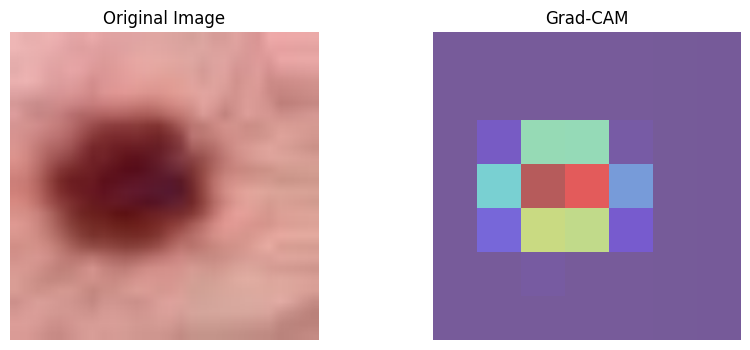

In [60]:
show_gradcam(efficientnet_derma, 'efficientnet', test_derma_eff, device, test_derma_raw.dataset)

In [61]:
indv_results_df = pd.DataFrame(indv_results)
indv_results_df

,Model,Dataset,Accuracy,Precision,Recall,F1-Score
0,ResNet50,PneumoniaMNIST,0.828526,0.865443,0.828526,0.813456
1,ResNet50,BreastMNIST,0.814103,0.836934,0.814103,0.779916
2,Resnet50,DermaMNIST,0.733167,0.764152,0.733167,0.741803
3,DenseNet121,PneumoniaMNIST,0.894231,0.908312,0.894231,0.889863
4,DenseNet121,BreastMNIST,0.858974,0.862130,0.858974,0.847007
5,DenseNet121,DermaMNIST,0.761097,0.777460,0.761097,0.765777
6,EfficientNetB0,PneumoniaMNIST,0.866987,0.884383,0.866987,0.860129
7,EfficientNetB0,BreastMNIST,0.846154,0.840813,0.846154,0.840664
8,EfficientNetB0,DermaMNIST,0.754613,0.778865,0.754613,0.762041


In [62]:
def kd_loss(student_logits, teacher_logits, labels, class_weights, T=3.0, alpha=0.7):
    
    ce = nn.CrossEntropyLoss(weight=class_weights)(student_logits, labels)
    
    kd = nn.KLDivLoss(reduction='batchmean')(
        F.log_softmax(student_logits / T, dim=1),
        F.softmax(teacher_logits / T, dim=1)
    ) * (T * T)
    
    return alpha * ce + (1 - alpha) * kd

In [63]:
def train_kd(student, teacher, train_loader, val_loader, class_weights):
    
    teacher.eval()
    for p in teacher.parameters():
        p.requires_grad = False

    optimizer = torch.optim.Adam(student.parameters(), lr=LR)
    early_stop = EarlyStopping(patience=5)

    for epoch in range(NUM_EPOCHS):
        student.train()
        train_loss = 0

        for images, labels in tqdm(train_loader):
            images = images.to(device)
            labels = labels.view(-1).long().to(device)

            optimizer.zero_grad()

            with torch.no_grad():
                teacher_logits = teacher(images)

            with torch.amp.autocast('cuda'):
                student_logits = student(images)
                loss = kd_loss(student_logits, teacher_logits, labels, class_weights)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()

        train_loss /= len(train_loader)

        student.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.view(-1).long().to(device)

                outputs = student(images)
                loss = nn.CrossEntropyLoss()(outputs, labels)

                val_loss += loss.item()

        val_loss /= len(val_loader)

        print(f"[KD] Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        early_stop.step(val_loss, student)
        if early_stop.stop:
            print("Early stopping KD")
            break

    early_stop.load_best(student)
    return student

In [64]:
def run_kd(teacher, train_loader, val_loader, test_loader, info, weights, dataset_name, teacher_name):
    
    student = get_model('efficientnet', len(info['label'])).to(device)

    student = train_kd(student, teacher, train_loader, val_loader, weights)

    acc, prec, rec, f1, _, _ = evaluate_model(student, test_loader)

    return {
        'Model': 'KD-EfficientNet',
        'Teacher': teacher_name,
        'Dataset': dataset_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1
    }

In [65]:
kd_results = []

In [66]:
# ResNet -> EfficientNet
kd_results.append(run_kd(
    resnet_pneu, train_pneu_eff, val_pneu_eff, test_pneu_eff,
    info_pneu_eff, class_weights_pneu_eff, 'PneumoniaMNIST', 'ResNet50'
))

kd_results.append(run_kd(
    resnet_breast, train_breast_eff, val_breast_eff, test_breast_eff,
    info_breast_eff, class_weights_breast_eff, 'BreastMNIST', 'ResNet50'
))

kd_results.append(run_kd(
    resnet_derma, train_derma_eff, val_derma_eff, test_derma_eff,
    info_derma_eff, class_weights_derma_eff, 'DermaMNIST', 'ResNet50'
))

100%|██████████| 74/74 [00:17<00:00,  4.26it/s]


[KD] Epoch 1 | Train: 0.7922 | Val: 0.1947


100%|██████████| 74/74 [00:16<00:00,  4.37it/s]


[KD] Epoch 2 | Train: 0.2021 | Val: 0.1097


100%|██████████| 74/74 [00:16<00:00,  4.37it/s]


...

[KD] Epoch 11 | Train: 0.5583 | Val: 0.6919


100%|██████████| 110/110 [00:42<00:00,  2.61it/s]


[KD] Epoch 12 | Train: 0.5492 | Val: 0.6971


100%|██████████| 110/110 [00:42<00:00,  2.62it/s]


[KD] Epoch 13 | Train: 0.5346 | Val: 0.6971
Early stopping KD
              precision    recall  f1-score   support

           0       0.42      0.41      0.41        66
           1       0.47      0.59      0.53       103
           2       0.63      0.39      0.48       220
           3       0.32      0.39      0.35        23
           4       0.46      0.54      0.50       223
           5       0.90      0.89      0.89      1341
           6       0.53      0.93      0.68        29

    accuracy                           0.76      2005
   macro avg       0.53      0.59      0.55      2005
weighted avg       0.77      0.76      0.76      2005



In [67]:
# DenseNet -> EfficientNet
kd_results.append(run_kd(
    densenet_pneu, train_pneu_eff, val_pneu_eff, test_pneu_eff,
    info_pneu_eff, class_weights_pneu_eff, 'PneumoniaMNIST', 'DenseNet121'
))

kd_results.append(run_kd(
    densenet_breast, train_breast_eff, val_breast_eff, test_breast_eff,
    info_breast_eff, class_weights_breast_eff, 'BreastMNIST', 'DenseNet121'
))

kd_results.append(run_kd(
    densenet_derma, train_derma_eff, val_derma_eff, test_derma_eff,
    info_derma_eff, class_weights_derma_eff, 'DermaMNIST', 'DenseNet121'
))

100%|██████████| 74/74 [00:18<00:00,  3.95it/s]


[KD] Epoch 1 | Train: 0.8075 | Val: 0.1398


100%|██████████| 74/74 [00:18<00:00,  4.10it/s]


[KD] Epoch 2 | Train: 0.2436 | Val: 0.0848


100%|██████████| 74/74 [00:18<00:00,  4.07it/s]


...

[KD] Epoch 16 | Train: 0.4786 | Val: 0.6559


100%|██████████| 110/110 [00:43<00:00,  2.52it/s]


[KD] Epoch 17 | Train: 0.4650 | Val: 0.6679


100%|██████████| 110/110 [00:43<00:00,  2.52it/s]


[KD] Epoch 18 | Train: 0.4577 | Val: 0.6539
Early stopping KD
              precision    recall  f1-score   support

           0       0.45      0.44      0.45        66
           1       0.50      0.70      0.58       103
           2       0.63      0.44      0.51       220
           3       0.60      0.39      0.47        23
           4       0.48      0.57      0.52       223
           5       0.90      0.88      0.89      1341
           6       0.44      0.93      0.60        29

    accuracy                           0.77      2005
   macro avg       0.57      0.62      0.58      2005
weighted avg       0.78      0.77      0.77      2005



In [68]:
indv_results_df['Teacher'] = '—' 
kd_results_df = pd.DataFrame(kd_results)

final_comparison = pd.concat([indv_results_df, kd_results_df], ignore_index=True)
final_comparison = final_comparison[['Teacher', 'Model', 'Dataset', 'Accuracy', 'Precision', 'Recall', 'F1-Score']]

print(final_comparison.to_string())

        Teacher            Model         Dataset  Accuracy  Precision    Recall  F1-Score
0             —         ResNet50  PneumoniaMNIST  0.828526   0.865443  0.828526  0.813456
1             —         ResNet50     BreastMNIST  0.814103   0.836934  0.814103  0.779916
2             —         Resnet50      DermaMNIST  0.733167   0.764152  0.733167  0.741803
3             —      DenseNet121  PneumoniaMNIST  0.894231   0.908312  0.894231  0.889863
4             —      DenseNet121     BreastMNIST  0.858974   0.862130  0.858974  0.847007
5             —      DenseNet121      DermaMNIST  0.761097   0.777460  0.761097  0.765777
6             —   EfficientNetB0  PneumoniaMNIST  0.866987   0.884383  0.866987  0.860129
7             —   EfficientNetB0     BreastMNIST  0.846154   0.840813  0.846154  0.840664
8             —   EfficientNetB0      DermaMNIST  0.754613   0.778865  0.754613  0.762041
9      ResNet50  KD-EfficientNet  PneumoniaMNIST  0.842949   0.874488  0.842949  0.830915
10     Res